In [8]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage, RemoveMessage
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
load_dotenv()

True

In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
llm = ChatOpenAI(model = "gpt-4o-mini")

In [10]:
def chat_node(state: ChatState):
    messages = []

    if state['summary']:
        messages.append(SystemMessage(content = f"Conversation Summary:\n{state['summary']}"))
    
    messages.extend(state['messages'])

    response = llm.invoke(messages)
    return {"messages": [response]}

In [7]:
def should_summarize(state: ChatState):
    return len(state['messages']) > 6

In [11]:
def summarize_conversation(state: ChatState):
    existing_summary = state['summary']
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."
    
    message_for_summary = state['messages'] + [HumanMessage(content = prompt)]

    response = llm.invoke(message_for_summary)

    # delete eaarlier messages and keep only last 2 messages
    messages_to_delete = state['messages'][:-2]
    return {
        "messages": [RemoveMessage(m.id) for m in messages_to_delete],
        "summary": response.content
    }

In [12]:
builder = StateGraph(ChatState)

builder.add_node("chat_node", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat_node")
builder.add_conditional_edges(
    "chat_node", 
    should_summarize, {
    True: "summarize",
    False: END
})
builder.add_edge("summarize", END)

In [13]:
graph = builder.compile(checkpointer = InMemorySaver())

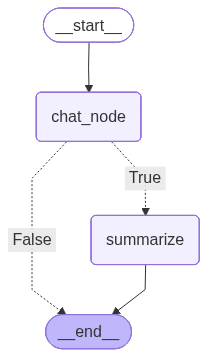

In [14]:
graph

In [ ]:
# This is my observation, not Nitish Sir's.

# Above graph is not that readable because by looking at the above visualization, these True and False on conditional edges are not clear.
# Just to improve the readability, we are gonna add a dummy node called 'should summarize'1_stm_persistence.ipynb
# Here is what I am talking about:

In [16]:
def dummy_node(state: ChatState):
    return state

In [17]:
builder = StateGraph(ChatState)

builder.add_node("chat_node", chat_node)
builder.add_node("summarize", summarize_conversation)
builder.add_node("summarization_needed", dummy_node)

builder.add_edge(START, "chat_node")
builder.add_edge("chat_node", "summarization_needed")
builder.add_conditional_edges(
    "summarization_needed", 
    should_summarize, {
    True: "summarize",
    False: END
})
builder.add_edge("summarize", END)

In [18]:
graph = builder.compile(checkpointer = InMemorySaver())

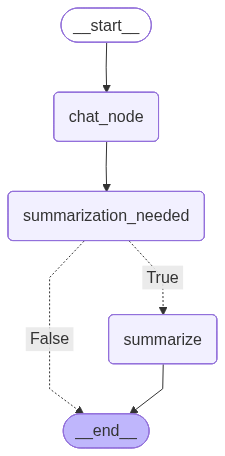

In [19]:
graph

In [20]:
# Now, this graph is more clear as we can see.

In [21]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [22]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [23]:
run_turn('Quantum Physics')
show_state()


--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics or quantum theory, is a fundame


In [24]:
run_turn('How is Albert Einstien related?')
show_state()


--- STATE ---
summary: 
num_messages: 4
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics or quantum theory, is a fundame
- HumanMessage : How is Albert Einstien related?
- AIMessage : Albert Einstein's contributions to physics, particularly through his theories of


In [25]:
run_turn('What are some of Einstien"s fampus work')
show_state()


--- STATE ---
summary: 
num_messages: 6
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics or quantum theory, is a fundame
- HumanMessage : How is Albert Einstien related?
- AIMessage : Albert Einstein's contributions to physics, particularly through his theories of
- HumanMessage : What are some of Einstien"s fampus work
- AIMessage : Albert Einstein is renowned for several groundbreaking contributions to physics,


In [26]:
run_turn('Explain special theory of relativity')
show_state()


--- STATE ---
summary: The conversation encompasses an overview of quantum physics and its relation to Albert Einstein, alongside a summary of Einstein's significant contributions and the Special Theory of Relativity.

1. **Quantum Physics**: Quantum physics describes nature at the atomic and subatomic levels, embracing concepts like wave-particle duality, quantum superposition, entanglement, the uncertainty principle, and quantum tunneling. It has crucial implications in various fields, including technology (e.g., quantum computing).

2. **Einstein’s Role**: Einstein contributed to quantum theory through his explanation of the photoelectric effect, which supported the idea of light as packets of energy (photons). Despite these contributions, he was apprehensive about the probabilistic nature of quantum mechanics and famously critiqued it through the EPR paradox, which questioned the completeness of quantum mechanics.

3. **Famous Works**: Key works by Einstein include the Special The